# CNN LeNet-5 – MNIST / Fashion MNIST / Medical MNIST

**So sánh 3 tầng:**
| Variant | Mô tả |
|---|---|
| **Baseline** | LeNet-5 gốc – Tanh + AvgPool |
| **Custom** | Riêng từng dataset – filter/depth được thiết kế theo độ khó |
| **Improved** | Chung cho cả 3 – ReLU + BN + Dropout + MaxPool |


## 0. Clone repo & Setup path

In [1]:
import os, sys

REPO_URL = 'https://github.com/PhuongThao-2005/MNIST-CNNLeNet5.git'
REPO_DIR = '/kaggle/working/MNIST-CNNLeNet5'

if not os.path.exists(REPO_DIR):
    os.system(f'git clone {REPO_URL} {REPO_DIR}')
else:
    os.system(f'git -C {REPO_DIR} pull')

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

print('Files:', os.listdir(REPO_DIR))

Cloning into '/kaggle/working/MNIST-CNNLeNet5'...


Files: ['kaggle_train.ipynb', '.gitignore', 'config.py', 'model.py', 'train.py', 'dataset.py', '.git']


## 1. Import

In [2]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import os

from config  import DEVICE, BATCH_SIZE, EPOCHS
from model   import LeNet5, LeNet5Improved, LeNet5_Handwritten, LeNet5_Fashion, LeNet5_Medical
from dataset import get_handwritten_mnist, get_fashion_mnist, get_medical_mnist
from train   import train_model

print(f'Device: {DEVICE} | Batch: {BATCH_SIZE} | Epochs: {EPOCHS}')

Device: cuda | Batch: 64 | Epochs: 20


## 2. Load Dataset

In [3]:
# Load datasets
handwritten_train, handwritten_test, handwritten_classes = get_handwritten_mnist(BATCH_SIZE)
fashion_train, fashion_test, fashion_classes = get_fashion_mnist(BATCH_SIZE)
medical_train, medical_test, medical_classes = get_medical_mnist(BATCH_SIZE)

datasets = {
    "handwritten": {
        "train": handwritten_train,
        "test": handwritten_test,
        "classes": handwritten_classes,
        "num_classes": len(handwritten_classes),
    },
    "fashion": {
        "train": fashion_train,
        "test": fashion_test,
        "classes": fashion_classes,
        "num_classes": len(fashion_classes),
    },
    "medical": {
        "train": medical_train,
        "test": medical_test,
        "classes": medical_classes,
        "num_classes": len(medical_classes),
    },
}

for name, info in datasets.items():
    n_train = len(info['train'].dataset)
    n_test  = len(info['test'].dataset)
    print(f'{name.upper():10s}: train={n_train:>6,}  test={n_test:>5,}  classes={info["num_classes"]}')
    print(f'  Labels: {info["classes"]}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 34.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.07MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.38MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.22MB/s]
100%|██████████| 26.4M/26.4M [00:01<00:00, 17.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 272kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.08MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.1MB/s]


HANDWRITTEN: train=60,000  test=10,000  classes=10
  Labels: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
FASHION   : train=60,000  test=10,000  classes=10
  Labels: ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
MEDICAL   : train=47,164  test=11,790  classes=6
  Labels: ['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']


## 3. Visualise mẫu dữ liệu

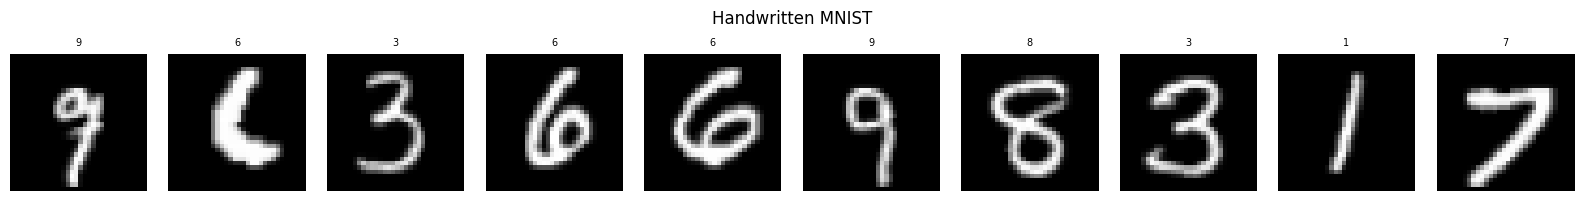

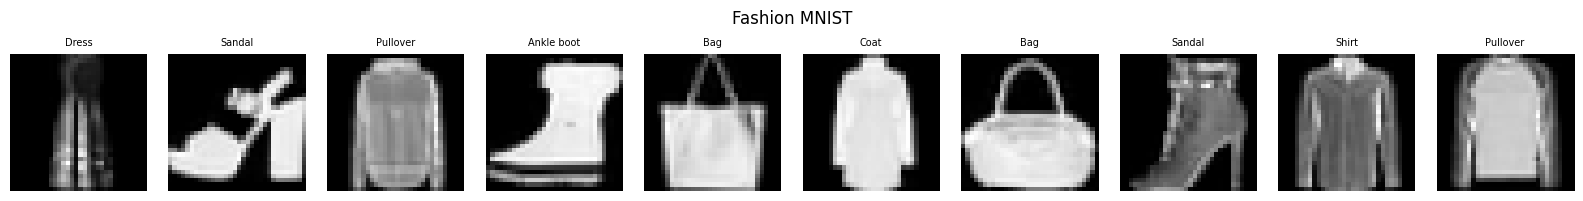

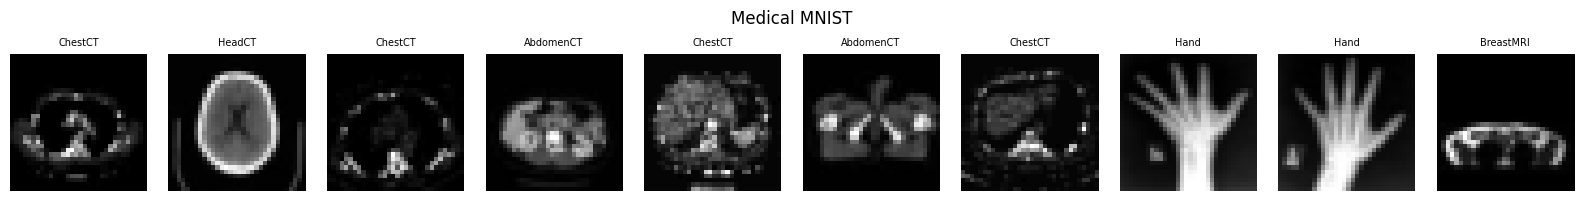

In [4]:
def show_samples(loader, class_names, title, n=10):
    images, labels = next(iter(loader))
    fig, axes = plt.subplots(1, n, figsize=(16, 2))
    fig.suptitle(title, fontsize=12)
    for i in range(n):
        axes[i].imshow(images[i].squeeze(), cmap='gray')
        axes[i].set_title(class_names[labels[i]], fontsize=7)
        axes[i].axis('off')
    plt.tight_layout(); plt.show()

show_samples(datasets['handwritten']['train'], datasets['handwritten']['classes'], 'Handwritten MNIST')
show_samples(datasets['fashion']['train'], datasets['fashion']['classes'], 'Fashion MNIST')
show_samples(datasets['medical']['train'], datasets['medical']['classes'], 'Medical MNIST')

## 4. So sánh kiến trúc 5 model

| Model          | Filters       | Layers     | FC          | Dropout   | Lý do                                         |
| -------------- | ------------- | ---------- | ----------- | --------- | --------------------------------------------- |
| Baseline       | 6→16          | 2 Conv     | 120→84      | Không     | Chuẩn gốc LeNet                               |
| Improved       | 6→16          | 2 Conv     | 120→84      | 0.4       | Thêm BN + ReLU + ổn định train                |
| MNIST Custom   | **6→12**      | 2 Conv     | **84**      | **0.3**   | MNIST đơn giản → giảm capacity, tránh overfit |
| Fashion Custom | **32→64→128** | **3 Conv** | **512→256** | **0.5×2** | Texture phức tạp → cần model lớn hơn          |
| Medical Custom | **4→8**       | 2 Conv     | **32**      | Không     | Dataset dễ phân biệt → model nhỏ đủ           |


In [5]:
models_info = [
    (LeNet5,          10, 'LeNet5 Baseline'),
    (LeNet5Improved,  10, 'LeNet5 Improved (chung)'),
    (LeNet5_Handwritten,  10, 'LeNet5_Handwritten  (riêng - nhẹ )'),
    (LeNet5_Fashion,  10, 'LeNet5_Fashion  (riêng - 3 conv)'),
    (LeNet5_Medical,   6, 'LeNet5_Medical  (riêng - deeper)'),
]

dummy = torch.zeros(2, 1, 32, 32)
print(f'{"Model":<38} {"Output":>14} {"Params":>12}')
print('-' * 66)
for cls, nc, name in models_info:
    m = cls(num_classes=nc)
    out = m(dummy)
    params = sum(p.numel() for p in m.parameters())
    print(f'{name:<38} {str(out.shape):>14} {params:>12,}')

Model                                          Output       Params
------------------------------------------------------------------
LeNet5 Baseline                        torch.Size([2, 10])       61,706
LeNet5 Improved (chung)                torch.Size([2, 10])       61,750
LeNet5_Handwritten  (riêng - nhẹ )     torch.Size([2, 10])       28,138
LeNet5_Fashion  (riêng - 3 conv)       torch.Size([2, 10])    1,276,618
LeNet5_Medical  (riêng - deeper)       torch.Size([2, 6])        7,566


## 5. Train Baseline trên cả 3 dataset

In [6]:
# Train baseline cho tất cả datasets
results = {}

for ds_name in ['handwritten', 'fashion', 'medical']:
    ds_info = datasets[ds_name]
    model, history = train_model(
        model=LeNet5(num_classes=ds_info['num_classes']),
        train_loader=ds_info['train'],
        test_loader=ds_info['test'],
        dataset=ds_name,
        variant='baseline',
        epochs=20,
        lr=0.001,
    )
    results[ds_name] = {'baseline': {'model': model, 'history': history}}


  Dataset : HANDWRITTEN  Variant : BASELINE
  Model   : LeNet5  (61,706 params)
  Epochs  : 20   LR: 0.001
--------------------------------------------------------------
Epoch 01/20  Loss:   243.79  Train: 0.9715  Test : 0.9693 <-  best
Epoch 02/20  Loss:    77.19  Train: 0.9841  Test : 0.9792 <-  best
Epoch 03/20  Loss:    53.85  Train: 0.9858  Test : 0.9820 <-  best
Epoch 04/20  Loss:    41.36  Train: 0.9906  Test : 0.9861 <-  best
Epoch 05/20  Loss:    33.68  Train: 0.9922  Test : 0.9858
Epoch 06/20  Loss:    28.77  Train: 0.9928  Test : 0.9857
Epoch 07/20  Loss:    23.62  Train: 0.9926  Test : 0.9854
Epoch 08/20  Loss:    21.69  Train: 0.9945  Test : 0.9855
Epoch 09/20  Loss:    17.07  Train: 0.9961  Test : 0.9863 <-  best
Epoch 10/20  Loss:    16.26  Train: 0.9964  Test : 0.9859
Epoch 11/20  Loss:     7.43  Train: 0.9987  Test : 0.9868 <-  best
Epoch 12/20  Loss:     4.56  Train: 0.9993  Test : 0.9880 <-  best
Epoch 13/20  Loss:     4.38  Train: 0.9986  Test : 0.9870
Epoch 14/20 

## 6. Train Custom cho từng dataset

In [7]:
# Train custom cho từng dataset
custom_models = {
    'handwritten': LeNet5_Handwritten,
    'fashion': LeNet5_Fashion,
    'medical': LeNet5_Medical
}

for ds_name in ['handwritten', 'fashion', 'medical']:
    ds_info = datasets[ds_name]
    model_class = custom_models[ds_name]
    model, history = train_model(
        model=custom_models[ds_name](num_classes=ds_info['num_classes']),
        train_loader=ds_info['train'],
        test_loader=ds_info['test'],
        dataset=ds_name,
        variant='custom',
        epochs=20,
        lr=0.001,
    )
    results[ds_name]['custom'] = {'model': model, 'history': history}


  Dataset : HANDWRITTEN  Variant : CUSTOM
  Model   : LeNet5_Handwritten  (28,138 params)
  Epochs  : 20   LR: 0.001
--------------------------------------------------------------
Epoch 01/20  Loss:   213.44  Train: 0.9823  Test : 0.9820 <-  best
Epoch 02/20  Loss:    73.45  Train: 0.9861  Test : 0.9843 <-  best
Epoch 03/20  Loss:    59.14  Train: 0.9883  Test : 0.9863 <-  best
Epoch 04/20  Loss:    48.27  Train: 0.9910  Test : 0.9883 <-  best
Epoch 05/20  Loss:    43.35  Train: 0.9906  Test : 0.9880
Epoch 06/20  Loss:    41.26  Train: 0.9934  Test : 0.9900 <-  best
Epoch 07/20  Loss:    34.84  Train: 0.9944  Test : 0.9897
Epoch 08/20  Loss:    34.34  Train: 0.9940  Test : 0.9907 <-  best
Epoch 09/20  Loss:    30.66  Train: 0.9952  Test : 0.9908 <-  best
Epoch 10/20  Loss:    28.34  Train: 0.9951  Test : 0.9906
Epoch 11/20  Loss:    20.44  Train: 0.9971  Test : 0.9920 <-  best
Epoch 12/20  Loss:    18.43  Train: 0.9970  Test : 0.9923 <-  best
Epoch 13/20  Loss:    17.82  Train: 0.9976

## 7. Train Improved trên cả 3 dataset

In [8]:
# Train improved cho tất cả datasets
for ds_name in ['handwritten', 'fashion', 'medical']:
    ds_info = datasets[ds_name]
    model, history = train_model(
        model=LeNet5Improved(num_classes=ds_info['num_classes']),
        train_loader=ds_info['train'],
        test_loader=ds_info['test'],
        dataset=ds_name,
        variant='improved',
        epochs=20,
        lr=0.001,
    )
    results[ds_name]['improved'] = {'model': model, 'history': history}


  Dataset : HANDWRITTEN  Variant : IMPROVED
  Model   : LeNet5Improved  (61,750 params)
  Epochs  : 20   LR: 0.001
--------------------------------------------------------------
Epoch 01/20  Loss:   195.36  Train: 0.9825  Test : 0.9821 <-  best
Epoch 02/20  Loss:    64.71  Train: 0.9864  Test : 0.9856 <-  best
Epoch 03/20  Loss:    47.93  Train: 0.9901  Test : 0.9883 <-  best
Epoch 04/20  Loss:    40.04  Train: 0.9934  Test : 0.9908 <-  best
Epoch 05/20  Loss:    34.31  Train: 0.9913  Test : 0.9865
Epoch 06/20  Loss:    29.36  Train: 0.9947  Test : 0.9907
Epoch 07/20  Loss:    25.21  Train: 0.9939  Test : 0.9888
Epoch 08/20  Loss:    21.84  Train: 0.9951  Test : 0.9912 <-  best
Epoch 09/20  Loss:    22.01  Train: 0.9943  Test : 0.9893
Epoch 10/20  Loss:    18.08  Train: 0.9967  Test : 0.9898
Epoch 11/20  Loss:    10.01  Train: 0.9988  Test : 0.9929 <-  best
Epoch 12/20  Loss:     7.99  Train: 0.9981  Test : 0.9925
Epoch 13/20  Loss:     7.81  Train: 0.9990  Test : 0.9917
Epoch 14/20  

In [9]:
# Bảng tổng hợp Best Test Accuracy
def print_summary(results):
    VARIANTS = ['baseline', 'custom', 'improved']
    header = f"{'Dataset':<12}" + "".join(f"{v.upper():>12}" for v in VARIANTS)
    sep    = "=" * (12 + 12 * len(VARIANTS))
    print(f"\n{sep}\n{header}\n{'-' * (12 + 12 * len(VARIANTS))}")
    for ds_name, ds_results in results.items():
        row = f"{ds_name.upper():<12}"
        for variant in VARIANTS:
            best = max(ds_results[variant]["history"]["test_acc"])
            row += f"{best:>12.4f}"
        print(row)
    print(sep)

print_summary(results)


Dataset         BASELINE      CUSTOM    IMPROVED
------------------------------------------------
HANDWRITTEN       0.9880      0.9929      0.9931
FASHION           0.8936      0.9269      0.9107
MEDICAL           0.9997      0.9997      0.9998


## 7. So sánh Accuracy Curve – 3 variant trên mỗi dataset

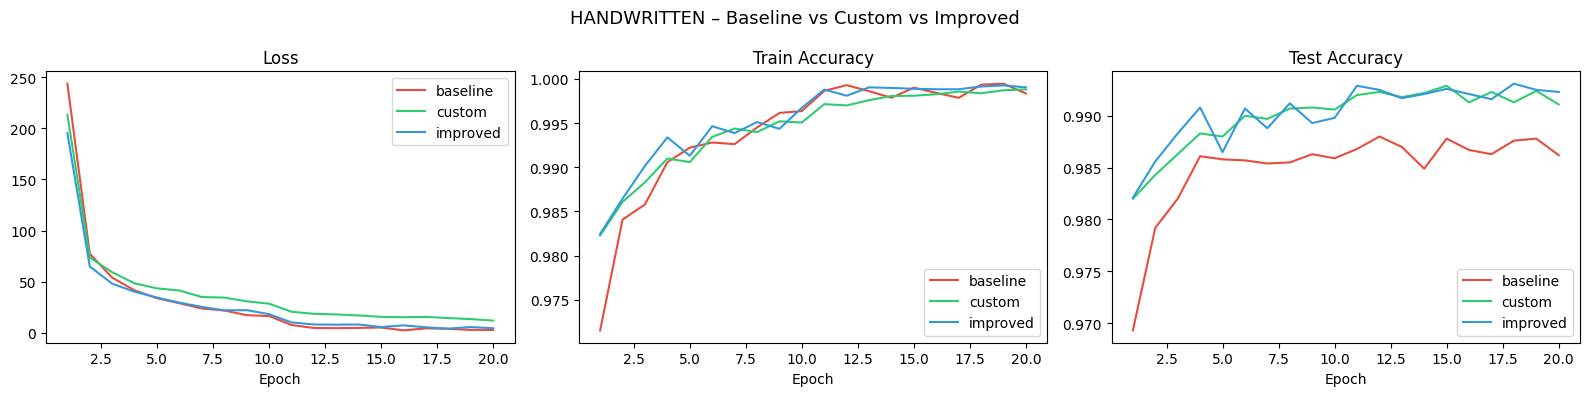

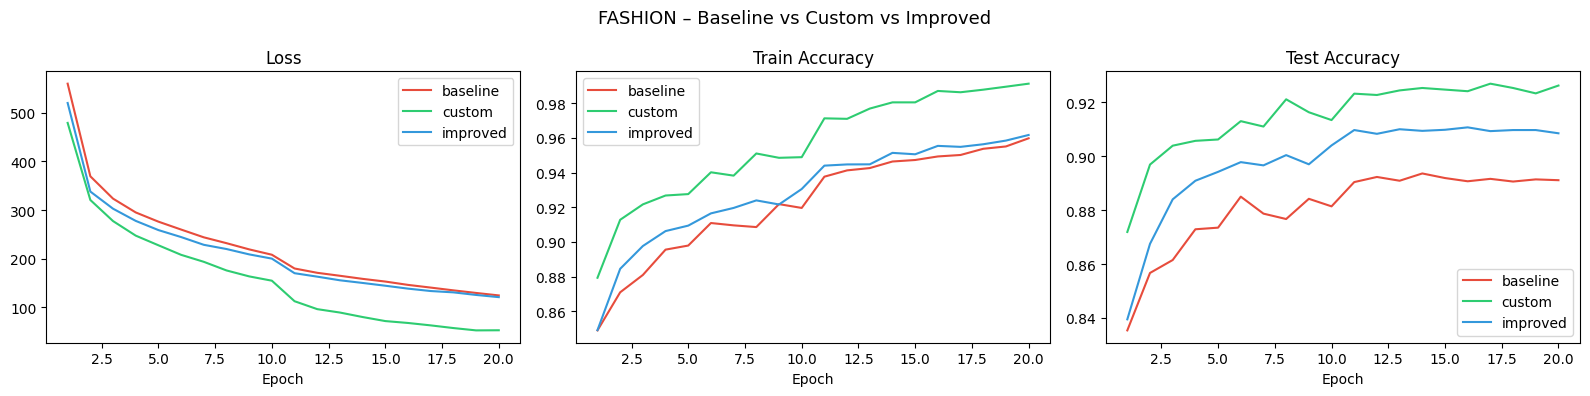

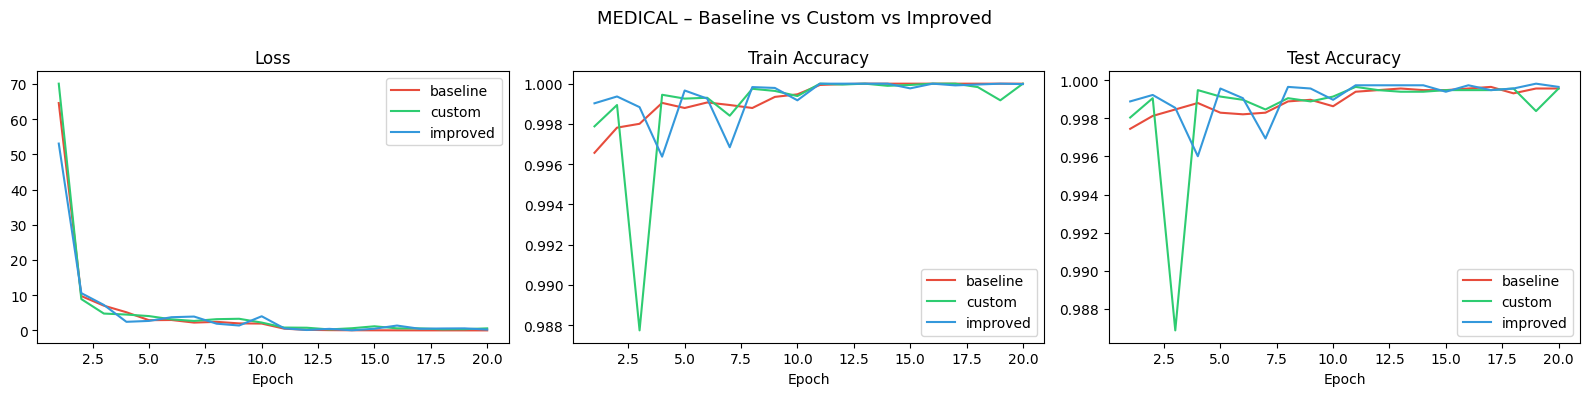

In [10]:
COLORS = {'baseline': '#e74c3c', 'improved': '#3498db', 'custom': '#2ecc71'}
VARIANTS = ['baseline', 'custom', 'improved']

def plot_all_variants(results, ds_name):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f'{ds_name.upper()} – Baseline vs Custom vs Improved', fontsize=13)

    for variant in VARIANTS:
        h = results[ds_name][variant]['history']
        ep = range(1, len(h['loss']) + 1)
        c  = COLORS[variant]
        axes[0].plot(ep, h['loss'],      color=c, label=variant)
        axes[1].plot(ep, h['train_acc'], color=c, label=variant)
        axes[2].plot(ep, h['test_acc'],  color=c, label=variant)

    for ax, title in zip(axes, ['Loss', 'Train Accuracy', 'Test Accuracy']):
        ax.set_title(title); ax.legend(); ax.set_xlabel('Epoch')

    plt.tight_layout(); plt.show()

for ds in ['handwritten', 'fashion', 'medical']:
    plot_all_variants(results, ds)

## 8. Confusion Matrix – Custom model (model tốt nhất)

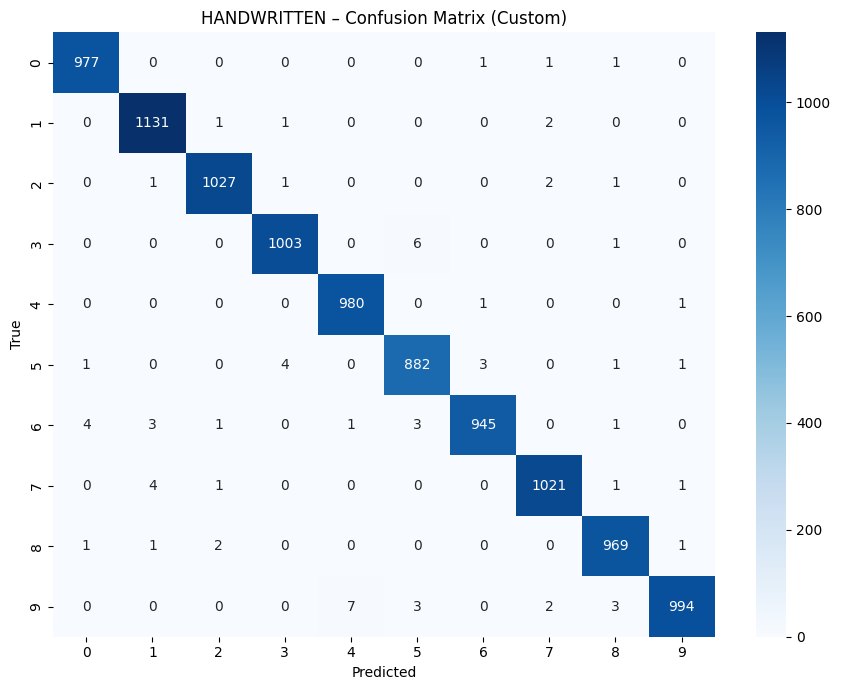

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      0.99      1135
           2       1.00      1.00      1.00      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



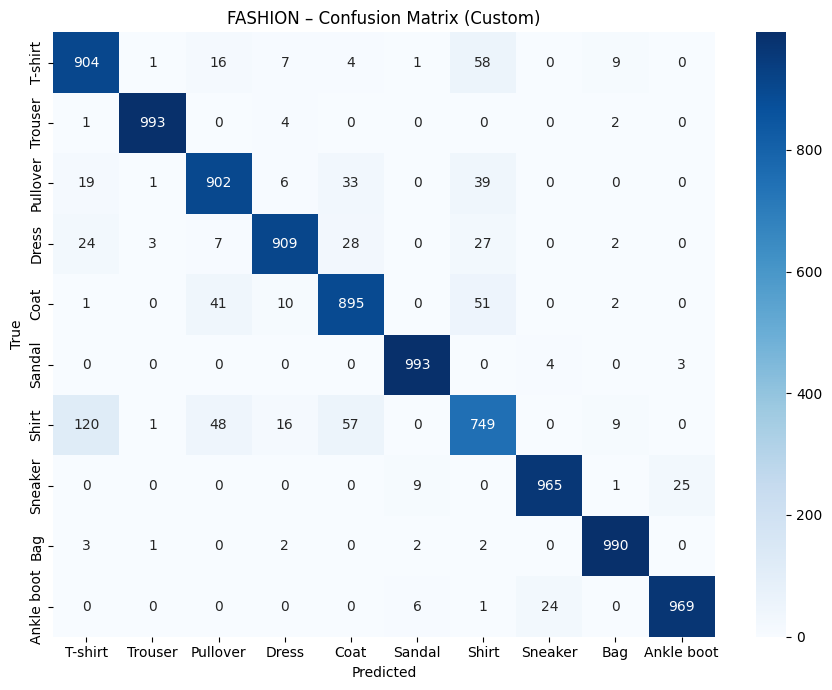

              precision    recall  f1-score   support

     T-shirt       0.84      0.90      0.87      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.89      0.90      0.90      1000
       Dress       0.95      0.91      0.93      1000
        Coat       0.88      0.90      0.89      1000
      Sandal       0.98      0.99      0.99      1000
       Shirt       0.81      0.75      0.78      1000
     Sneaker       0.97      0.96      0.97      1000
         Bag       0.98      0.99      0.98      1000
  Ankle boot       0.97      0.97      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



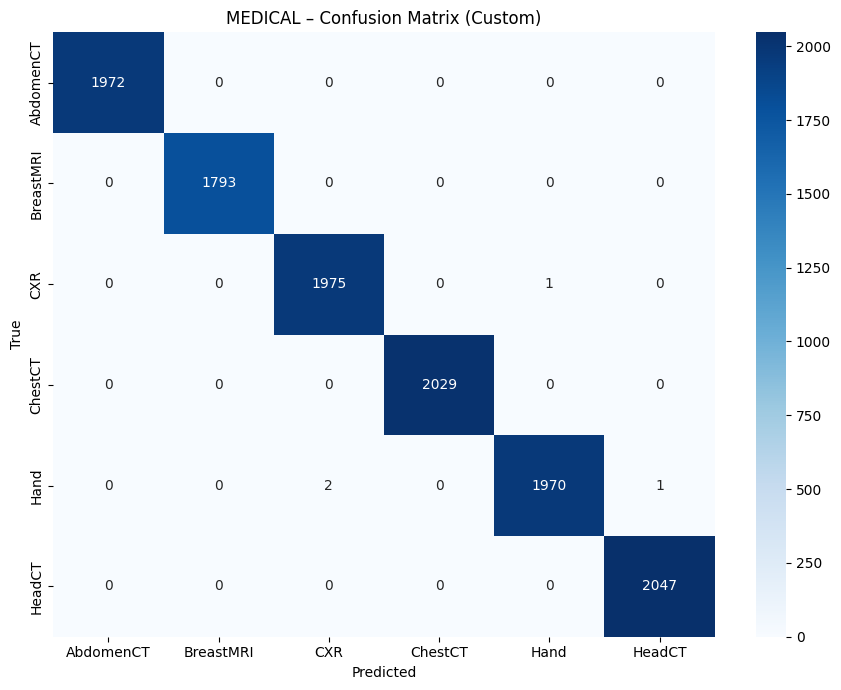

              precision    recall  f1-score   support

   AbdomenCT       1.00      1.00      1.00      1972
   BreastMRI       1.00      1.00      1.00      1793
         CXR       1.00      1.00      1.00      1976
     ChestCT       1.00      1.00      1.00      2029
        Hand       1.00      1.00      1.00      1973
      HeadCT       1.00      1.00      1.00      2047

    accuracy                           1.00     11790
   macro avg       1.00      1.00      1.00     11790
weighted avg       1.00      1.00      1.00     11790



In [13]:
def get_predictions(model, loader):
    model.eval()
    preds_all, labels_all, images_all = [], [], []
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            p    = model(X).argmax(dim=1)
            preds_all.extend(p.cpu().numpy())
            labels_all.extend(y.cpu().numpy())
            images_all.extend(X.cpu())
    return preds_all, labels_all, images_all


def plot_confusion_matrix(preds, labels, class_names, title):
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    plt.tight_layout(); plt.show()


# Đánh giá trên Custom model
for ds_name in ['handwritten', 'fashion', 'medical']:
    model   = results[ds_name]['custom']['model']
    loader  = datasets[ds_name]['test']
    classes = datasets[ds_name]['classes']

    preds, labels, images = get_predictions(model, loader)
    plot_confusion_matrix(preds, labels, classes,
                          f'{ds_name.upper()} – Confusion Matrix (Custom)')
    print(classification_report(labels, preds, target_names=classes))

    datasets[ds_name]['preds']  = preds
    datasets[ds_name]['labels'] = labels
    datasets[ds_name]['images'] = images

## 9. Ảnh dự đoán sai – Custom model

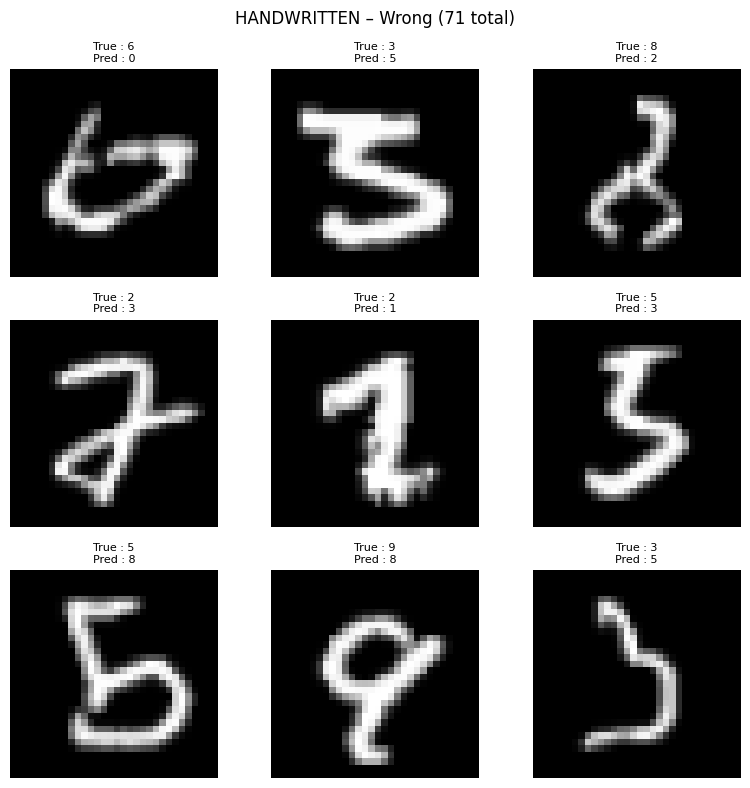

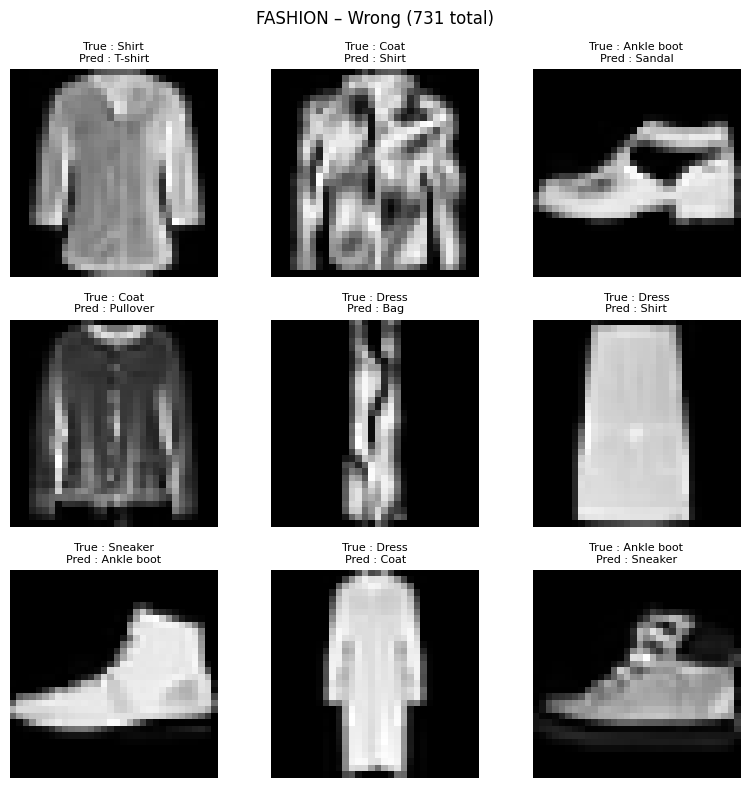

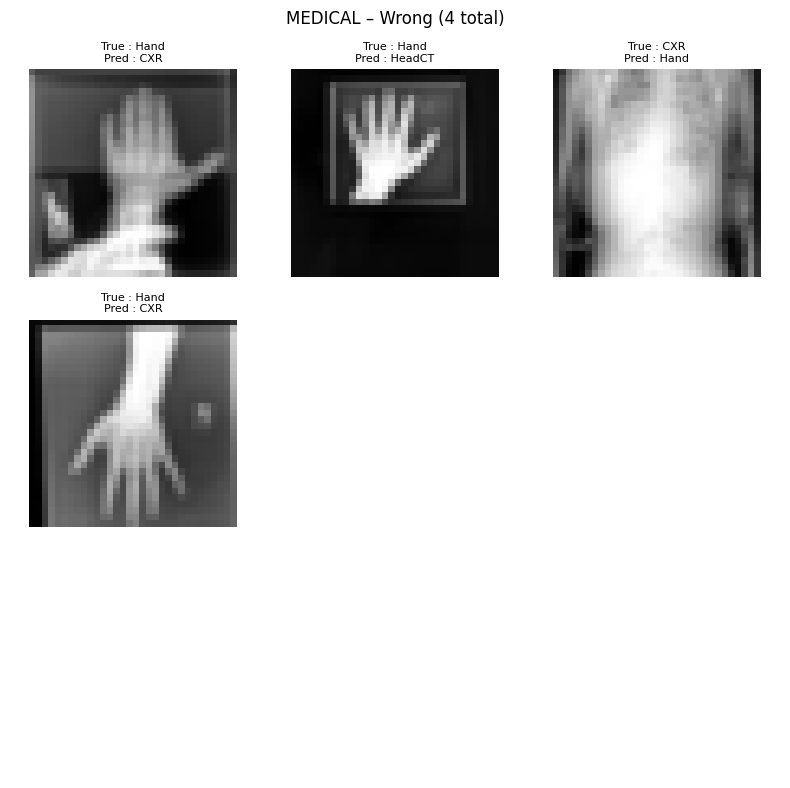

In [14]:
def show_wrong_predictions(images, preds, labels, class_names, title, num_images=9):
    wrong = [i for i in range(len(preds)) if preds[i] != labels[i]]
    if not wrong:
        print('Không có dự đoán sai!'); return
    n   = min(num_images, len(wrong))
    fig, axes = plt.subplots(3, 3, figsize=(8, 8))
    fig.suptitle(f'{title} – Wrong ({len(wrong):,} total)', fontsize=12)
    for i, ax in enumerate(axes.flatten()):
        if i >= n:
            ax.axis('off'); continue
        idx = wrong[i]
        ax.imshow(images[idx].squeeze(), cmap='gray')
        ax.set_title(
            f'True : {class_names[labels[idx]]}\nPred : {class_names[preds[idx]]}',
            fontsize=8)
        ax.axis('off')
    plt.tight_layout(); plt.show()

for ds_name in ['handwritten', 'fashion', 'medical']:
    show_wrong_predictions(
        datasets[ds_name]['images'], datasets[ds_name]['preds'],
        datasets[ds_name]['labels'], datasets[ds_name]['classes'],
        ds_name.upper()
    )